# BERT Fake-News Classifier

## Step 0 — Install libraries


In [ ]:
!pip install -q "transformers>=4.40" "datasets>=2.18" "accelerate>=0.30" scikit-learn

## Step 1 — Mount Google Drive

This is where your cleaned CSV lives and where the trained model will be saved.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/MS_Thesis'

Mounted at /content/drive


## Step 2 — Imports and GPU check


In [ ]:
import inspect
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


## Step 3 — Load the cleaned data

This loads `clean_welfake.csv` that we have already
produced (63,121 rows of `content` + `label`).

If for some reason that file is gone, un-comment the rebuild block below to
recreate it from the original `archive (1).zip`.


In [ ]:
df = pd.read_csv(f"{DRIVE_DIR}/clean_welfake.csv")

# --- Rebuild from scratch only if clean_welfake.csv is missing ---
# df = pd.read_csv("archive (1).zip")          # the original WELFake zip
# df = df.dropna()
# df["content"] = df["title"] + " " + df["text"]
# df = df[["content", "label"]].drop_duplicates()
# df.to_csv(f"{DRIVE_DIR}/clean_welfake.csv", index=False)

df = df.dropna(subset=["content", "label"])
df["content"] = df["content"].astype(str)
df["label"] = df["label"].astype(int)

print("Shape:", df.shape)
print(df["label"].value_counts())
df.head()

Shape: (63121, 2)
label
0    34791
1    28330
Name: count, dtype: int64


,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
2,"Bobby Jindal, raised Hindu, uses story of Chri...",0
3,SATAN 2: Russia unvelis an image of its terrif...,1
4,About Time! Christian Group Sues Amazon and SP...,1


## Step 4 — Train / test split

80% train, 20% test. `stratify=y` keeps the real/fake ratio the same in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"],
)

print("Train:", X_train.shape[0], " Test:", X_test.shape[0])

Train: 50496  Test: 12625


## Step 5 — Tokenizer
The original code did:

```python
train_encodings = tokenizer(X_train.tolist(), padding='max_length', max_length=256)
```

which builds enormous Python lists in RAM and pads *everything* to 256 tokens.
That is what blew up Colab.

Here we instead:
- put the data into a Hugging Face `Dataset` (backed by disk, not RAM),
- tokenize in batches with `.map()` so memory stays flat,
- **do not pad here** — a `DataCollatorWithPadding` will pad each *batch* to its
  own longest item during training. Much less memory, and faster.


In [ ]:
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Build small DataFrames -> HF Datasets. Trainer expects the label column
# to be named "labels". reset_index(drop=True) avoids a stray index column.
train_df = pd.DataFrame({"text": X_train, "labels": y_train}).reset_index(drop=True)
test_df  = pd.DataFrame({"text": X_test,  "labels": y_test }).reset_index(drop=True)

train_ds = Dataset.from_pandas(train_df)
test_ds  = Dataset.from_pandas(test_df)

def tokenize(batch):
    # NOTE: no padding here on purpose — the collator handles it per-batch.
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_ds = train_ds.map(tokenize, batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize,  batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_ds)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/50496 [00:00<?, ? examples/s]

Map:   0%|          | 0/12625 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 50496
})


In [ ]:
sample = X_train.iloc[0]          # one article from the training set

# 1) BEFORE: the raw English text
print("1) RAW TEXT")
print(sample[:300], "...\n")

# 2) TOKENS: split into BERT word-pieces (note the ## continuation pieces)
tokens = tokenizer.tokenize(sample)
print("2) TOKENS  (first 25 of", len(tokens), "):")
print(tokens[:25], "\n")

# 3) ENCODED VECTOR: the integer IDs BERT actually reads
enc = tokenizer(sample, truncation=True, max_length=MAX_LENGTH)
print("3) input_ids  (first 25 of", len(enc["input_ids"]), "):")
print(enc["input_ids"][:25])
print("   attention_mask (first 25):")
print(enc["attention_mask"][:25], "\n")

# 4) Sanity check: turn the IDs back into text to prove it's reversible
print("4) DECODED BACK FROM IDS:")
print(tokenizer.decode(enc["input_ids"][:25]))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1074 > 512). Running this sequence through the model will result in indexing errors


1) RAW TEXT
Trump tweets about Russia probe spark warnings from lawmakers WASHINGTON/NEW YORK (Reuters) - A series of tweets by U.S. President Donald Trump about the investigation into contacts between his 2016 campaign and Russia prompted concerns on Sunday among both Democratic and Republican lawmakers, with  ...

2) TOKENS  (first 25 of 1074 ):
['trump', 't', '##wee', '##ts', 'about', 'russia', 'probe', 'spark', 'warnings', 'from', 'law', '##makers', 'washington', '/', 'new', 'york', '(', 'reuters', ')', '-', 'a', 'series', 'of', 't', '##wee'] 

3) input_ids  (first 25 of 256 ):
[101, 8398, 1056, 28394, 3215, 2055, 3607, 15113, 12125, 16234, 2013, 2375, 12088, 2899, 1013, 2047, 2259, 1006, 26665, 1007, 1011, 1037, 2186, 1997, 1056]
   attention_mask (first 25):
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 

4) DECODED BACK FROM IDS:
[CLS] trump tweets about russia probe spark warnings from lawmakers washington / new york ( reuters ) - a series of t


## Step 6 — Load the BERT model

`num_labels=2` because it's a binary classification (real vs. fake).

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Step 7 — Metrics function

This is what was missing before. After each evaluation the Trainer will call
this and report **accuracy, precision, recall and F1**.

`average='binary'` reports the metrics for the positive class (label = 1, i.e.
fake). Switch to `average='macro'` if you'd rather average both classes equally.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

## Step 8 — Training settings

Written to work across transformers versions (the `evaluation_strategy`
argument was renamed to `eval_strategy` in newer releases — Colab currently
ships a version that uses the new name, so we detect it automatically).

If you ever get a **GPU out-of-memory** error here (different from the RAM
crash), lower `per_device_train_batch_size` to 8.


In [ ]:
# Detect the correct name for the eval-strategy argument across versions.
ta_params = inspect.signature(TrainingArguments.__init__).parameters
eval_key = "eval_strategy" if "eval_strategy" in ta_params else "evaluation_strategy"

args_kwargs = dict(
    output_dir=f"{DRIVE_DIR}/results",
    num_train_epochs=3,                  # 2-3 is typical; raise for better scores
    per_device_train_batch_size=16,      # drop to 8 if GPU runs out of memory
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),      # half precision on GPU -> faster, less memory
)
args_kwargs[eval_key] = "epoch"          # evaluate at the end of every epoch

training_args = TrainingArguments(**args_kwargs)

## Step 9 — Train

This is the long step. On a free T4 GPU, ~50k examples for 2 epochs takes roughly 20–40 minutes.

In [ ]:
# `tokenizer` was renamed to `processing_class` in newer transformers; detect it.
trainer_params = inspect.signature(Trainer.__init__).parameters
proc_key = "processing_class" if "processing_class" in trainer_params else "tokenizer"

trainer_kwargs = {
    "model": model,
    "args": training_args,
    "train_dataset": train_ds,
    "eval_dataset": test_ds,
    "data_collator": data_collator,
    "compute_metrics": compute_metrics,
    proc_key: tokenizer,
}

trainer = Trainer(**trainer_kwargs)
trainer.train()

## Step 10 — Evaluate: F1, precision, recall

First the headline numbers, then a full per-class breakdown.

In [ ]:
metrics = trainer.evaluate()
print("Overall metrics:")
for k, v in metrics.items():
    if k.startswith("eval_"):
        print(f"  {k.replace('eval_', ''):12s}: {v:.4f}")

In [ ]:
# Detailed, per-class report + confusion matrix
pred_output = trainer.predict(test_ds)
y_pred = np.argmax(pred_output.predictions, axis=-1)
y_true = pred_output.label_ids

print(classification_report(
    y_true, y_pred,
    target_names=["real (0)", "fake (1)"],
    digits=4,
))

print("Confusion matrix [rows = true, cols = predicted]:")
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

    real (0)     0.9970    0.9930    0.9950      6959
    fake (1)     0.9914    0.9963    0.9938      5666

    accuracy                         0.9945     12625
   macro avg     0.9942    0.9946    0.9944     12625
weighted avg     0.9945    0.9945    0.9945     12625

Confusion matrix [rows = true, cols = predicted]:
[[6910   49]
 [  21 5645]]


## Step 11 — Save the trained model

So you don't have to retrain next time — load it back with `from_pretrained(SAVE_DIR)`.

In [ ]:
SAVE_DIR = f"{DRIVE_DIR}/bert_fakenews_model"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("Saved to", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /content/drive/MyDrive/MS_Thesis/bert_fakenews_model


# Prediction from trained model

In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# If you're in a fresh session, make sure DRIVE_DIR is set:
# DRIVE_DIR = '/content/drive/MyDrive/MS_Thesis'
SAVE_DIR = f"{DRIVE_DIR}/bert_fakenews_model"

tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()   # turn off training behaviour (dropout etc.)

LABELS = {0: "REAL", 1: "FAKE"}   # matches how the data was labelled
print("Model loaded on", device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded on cuda


In [ ]:
def predict_article(text, max_length=256, show_tokens=True):

    # 1) RAW TEXT
    print("=" * 60)
    print("RAW TEXT (first 300 chars):")
    print(text[:300], "...\n" if len(text) > 300 else "\n")

    # 2) TOKENS
    tokens = tokenizer.tokenize(text)

    if show_tokens:
        print(f"TOKENS (first 25 of {len(tokens)}):")
        print(tokens[:25], "\n")

    # 3) ENCODED VECTOR
    enc = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )

    print(f"input_ids (first 25 of {enc['input_ids'].shape[1]}):")
    print(enc["input_ids"][0][:25].tolist(), "\n")

    # 4) Prediction
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits

    probs = F.softmax(logits, dim=-1)[0]

    pred = int(torch.argmax(probs))

    print("Prediction:", LABELS[pred])
    print(f"Confidence: {probs[pred].item()*100:.2f}%")
    print(f"REAL: {probs[0].item()*100:.2f}%")
    print(f"FAKE: {probs[1].item()*100:.2f}%")

    return LABELS[pred], probs.tolist()

In [ ]:
pred_output = trainer.predict(test_ds)

y_pred = np.argmax(pred_output.predictions, axis=1)

y_true = pred_output.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=["Real","Fake"],
    digits=4
))

              precision    recall  f1-score   support

        Real     0.9970    0.9930    0.9950      6959
        Fake     0.9914    0.9963    0.9938      5666

    accuracy                         0.9945     12625
   macro avg     0.9942    0.9946    0.9944     12625
weighted avg     0.9945    0.9945    0.9945     12625



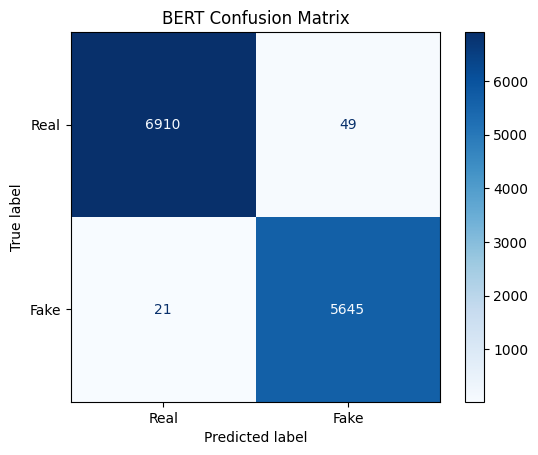

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real","Fake"]
)

disp.plot(cmap="Blues")

plt.title("BERT Confusion Matrix")

plt.show()

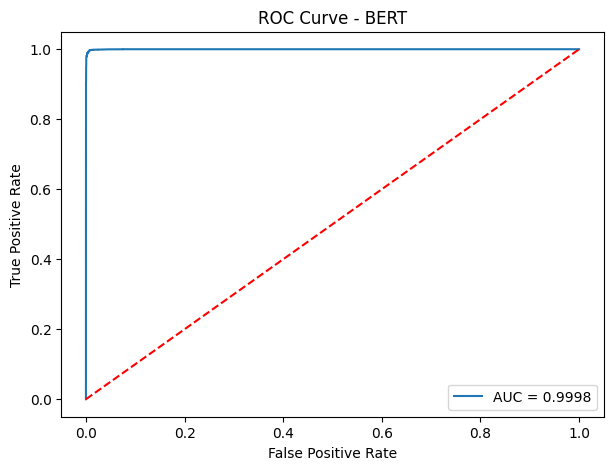

ROC AUC : 0.99982607016935


In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

probs = torch.softmax(
    torch.tensor(pred_output.predictions),
    dim=1
).numpy()[:,1]

fpr,tpr,_ = roc_curve(y_true,probs)

auc = roc_auc_score(y_true,probs)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label=f"AUC = {auc:.4f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - BERT")

plt.legend()

plt.show()

print("ROC AUC :",auc)

In [ ]:
import pandas as pd

results = pd.DataFrame({

"Model":[
"Logistic Regression",
"BERT"
],

"Accuracy":[
94.36,
99.43
],

"Precision":[
93.82,
99.23
],

"Recall":[
95.22,
99.51
],

"F1 Score":[
94.52,
99.37
]

})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     94.36      93.82   95.22     94.52
1                 BERT     99.43      99.23   99.51     99.37


In [ ]:
import pandas as pd

results = pd.DataFrame({

"Model":[
"Logistic Regression",
"BERT"
],

"Accuracy":[
94.36,
99.43
],

"Precision":[
93.82,
99.23
],

"Recall":[
95.22,
99.51
],

"F1 Score":[
94.52,
99.37
]

})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     94.36      93.82   95.22     94.52
1                 BERT     99.43      99.23   99.51     99.37


In [ ]:
!pip install shap

import shap

# Background data
explainer = shap.LinearExplainer(logistic_model, X_train)

# SHAP values
shap_values = explainer.shap_values(X_test)

# Summary Plot
shap.summary_plot(shap_values, X_test)

NameError: name 'logistic_model' is not defined

In [ ]:
text = input("Enter News:\n")

predict_article(text)

KeyboardInterrupt: Interrupted by user

In [ ]:
er.tokenize(text)
    if show_tokens:
        print(f"TOKENS  (first 25 of {len(tokens)}):")
        print(tokens[:25], "\n")def predict_article(text, max_length=256, show_tokens=True):
    # 1) RAW TEXT
    print("=" * 60)
    print("RAW TEXT (first 300 chars):")
    print(text[:300], "...\n" if len(text) > 300 else "\n")

    # 2) TOKENS — the word-pieces BERT splits the text into
    tokens = tokeniz

    # 3) ENCODED VECTOR — the integer IDs the model actually reads
    enc = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",   # return PyTorch tensors, ready for the model
    )
    print(f"input_ids (first 25 of {enc['input_ids'].shape[1]}):")
    print(enc["input_ids"][0][:25].tolist(), "\n")

    # 4) PREDICTION
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():                 # no gradients needed for inference
        logits = model(**enc).logits
    probs = F.softmax(logits, dim=-1)[0]  # convert scores to probabilities
    pred = int(torch.argmax(probs))

    print("PREDICTION:", LABELS[pred])
    print(f"   confidence: {probs[pred].item()*100:.1f}%")
    print(f"   (REAL: {probs[0].item()*100:.1f}%  |  FAKE: {probs[1].item()*100:.1f}%)")
    print("=" * 60)
    return LABELS[pred], probs.tolist()

IndentationError: unexpected indent (3320436157.py, line 2)

In [ ]:
print("Paste a news article (title + text) and press Enter:\n")
user_text = input("> ")

predict_article(user_text)

Paste a news article (title + text) and press Enter:



KeyboardInterrupt: Interrupted by user

In [ ]:
pred_output = trainer.predict(test_ds)
y_pred = np.argmax(pred_output.predictions, axis=-1)
y_true = pred_output.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=["real (0)", "fake (1)"],
    digits=4,
))

print("Confusion matrix [rows = true, cols = predicted]:")
print(confusion_matrix(y_true, y_pred))

NameError: name 'trainer' is not defined